# 01 - EDA de comparacion por empresas

Este notebook tiene un objetivo exploratorio: revisar si el mismo medicamento base, definido por la misma composicion y dosis, presenta diferencias entre empresas en aprobacion y efectos secundarios reportados.

Preguntas centrales de este EDA:
- como se distribuye el dataset entre empresas;
- si las columnas de reviews son consistentes para usarlas en comparaciones;
- cuantas composiciones equivalentes aparecen en mas de una empresa;
- si para una misma composicion cambian las reviews o los efectos secundarios segun el fabricante;
- que outliers, inconsistencias o relaciones conviene revisar antes de limpiar y transformar.

En este notebook no se limpia de forma definitiva ni se construyen rankings finales. La idea es diagnosticar el problema y dejar decisiones bien justificadas para las siguientes etapas.


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.load_data import load_medicine_data
from src.enfoque_02_comparacion_empresas.cleaning import canonicalize_composition, count_side_effects

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)

df = load_medicine_data(download_if_missing=False).copy()
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Dataset cargado: 11,825 filas x 9 columnas


,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lung cancer Kidney cancer Brain tumor Ovarian cancer Cervical cancer,Rectal bleeding Taste change Headache Nosebleeds Back pain Dry skin High blood pressure Protein in urine Inflammation of the nose,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/f5a26c491e4d48199ab116a69a969be3.jpg",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidiasis,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/wy2y9bdipmh6rgkrj0zm.jpg",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/cropped/kqkouvaqejbyk47dvjfu.jpg",Alembic Pharmaceuticals Ltd,39,40,21
3,Ascoril LS Syrup,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml) + Guaifenesin (50mg/5ml),Treatment of Cough with mucus,Nausea Vomiting Diarrhea Upset stomach Stomach pain Allergic reaction Dizziness Headache Rash Hives Tremors Palpitations Muscle cramp In...,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/3205599cc49d4073ae66cbb0dbfded86.jpg",Glenmark Pharmaceuticals Ltd,24,41,35
4,Aciloc 150 Tablet,Ranitidine (150mg),Treatment of Gastroesophageal reflux disease (Acid reflux)Treatment of Peptic ulcer disease,Headache Diarrhea Gastrointestinal disturbance,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/cropped/pn7apngctvrtweencwi1.jpg",Cadila Pharmaceuticals Ltd,34,37,29


## 1. Preparacion minima para explorar este foco

Para no modificar el dataset original, se crean estructuras auxiliares solo para inspeccion:
- `empresa`: normaliza espacios en `Manufacturer` para comparar mejor nombres iguales escritos con distinto espaciado;
- `composition_key`: agrupa composiciones equivalentes y permite tratar `A + B` como igual a `B + A`;
- `effect_count_estimate`: aproximacion al numero de efectos secundarios listados en texto;
- las tres columnas de reviews se convierten a numericas para revisar consistencia y comparar empresas.

Estas estructuras son temporales y se usan solo para el EDA.


In [2]:
review_cols = ["Excellent Review %", "Average Review %", "Poor Review %"]
review_data = df[review_cols].apply(pd.to_numeric, errors="coerce")
empresa = df["Manufacturer"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
composition_key = df["Composition"].apply(canonicalize_composition)
effect_count_estimate = df["Side_effects"].apply(count_side_effects)

exploration_df = pd.DataFrame(
    {
        "Medicine Name": df["Medicine Name"],
        "Manufacturer": df["Manufacturer"],
        "empresa": empresa,
        "Composition": df["Composition"],
        "composition_key": composition_key,
        "Side_effects": df["Side_effects"],
        "effect_count_estimate": effect_count_estimate,
    }
).join(review_data)

display(exploration_df.head())


,Medicine Name,Manufacturer,empresa,Composition,composition_key,Side_effects,effect_count_estimate,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Roche Products India Pvt Ltd,Roche Products India Pvt Ltd,Bevacizumab (400mg),Bevacizumab (400mg),Rectal bleeding Taste change Headache Nosebleeds Back pain Dry skin High blood pressure Protein in urine Inflammation of the nose,9,22,56,22
1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,Glaxo SmithKline Pharmaceuticals Ltd,Amoxycillin (500mg) + Clavulanic Acid (125mg),Amoxycillin (500mg) + Clavulanic Acid (125mg),Vomiting Nausea Diarrhea Mucocutaneous candidiasis,4,47,35,18
2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,Alembic Pharmaceuticals Ltd,Azithromycin (500mg),Azithromycin (500mg),Nausea Abdominal pain Diarrhea,3,39,40,21
3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,Glenmark Pharmaceuticals Ltd,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml) + Guaifenesin (50mg/5ml),Ambroxol (30mg/5ml) + Guaifenesin (50mg/5ml) + Levosalbutamol (1mg/5ml),Nausea Vomiting Diarrhea Upset stomach Stomach pain Allergic reaction Dizziness Headache Rash Hives Tremors Palpitations Muscle cramp In...,14,24,41,35
4,Aciloc 150 Tablet,Cadila Pharmaceuticals Ltd,Cadila Pharmaceuticals Ltd,Ranitidine (150mg),Ranitidine (150mg),Headache Diarrhea Gastrointestinal disturbance,3,34,37,29


## 2. Chequeos basicos e inconsistencias visibles

Antes de comparar empresas, conviene verificar si hay problemas estructurales en las variables clave:
- nulos en fabricante, composicion, efectos o reviews;
- porcentajes fuera del rango 0 a 100;
- filas donde las reviews no sumen 100;
- composiciones vacias despues de canonizar;
- duplicados exactos;
- posibles variantes de nombres de empresa que colapsen al normalizar espacios.


In [3]:
invalid_review_mask = (
    review_data.isna().any(axis=1)
    | ((review_data < 0) | (review_data > 100)).any(axis=1)
    | (review_data.sum(axis=1) != 100)
)

manufacturer_norm_map = exploration_df[["Manufacturer", "empresa"]].drop_duplicates()
manufacturer_variant_counts = (
    manufacturer_norm_map.groupby("empresa")["Manufacturer"]
    .nunique()
    .sort_values(ascending=False)
)

basic_checks = pd.DataFrame(
    {
        "metrica": [
            "filas_totales",
            "columnas_totales",
            "duplicados_exactos",
            "nulos_manufacturer",
            "nulos_composition",
            "nulos_side_effects",
            "filas_con_reviews_invalidas",
            "reviews_fuera_de_0_100",
            "filas_con_suma_reviews_distinta_de_100",
            "composition_key_vacia",
            "empresas_con_variantes_tras_normalizar_espacios",
        ],
        "valor": [
            int(df.shape[0]),
            int(df.shape[1]),
            int(df.duplicated().sum()),
            int(df["Manufacturer"].isna().sum()),
            int(df["Composition"].isna().sum()),
            int(df["Side_effects"].isna().sum()),
            int(invalid_review_mask.sum()),
            int(((review_data < 0) | (review_data > 100)).any(axis=1).sum()),
            int((review_data.sum(axis=1) != 100).sum()),
            int(composition_key.eq("").sum()),
            int((manufacturer_variant_counts > 1).sum()),
        ],
    }
)

display(basic_checks)

print("Primeras filas duplicadas exactas:")
display(df[df.duplicated()].head())

print("Posibles variantes de fabricante tras normalizar espacios:")
display(manufacturer_variant_counts[manufacturer_variant_counts > 1].head(10))

print("Filas con problemas en las reviews:")
display(exploration_df.loc[invalid_review_mask].head())


,metrica,valor
0,filas_totales,11825
1,columnas_totales,9
2,duplicados_exactos,84
3,nulos_manufacturer,0
4,nulos_composition,0
5,nulos_side_effects,0
6,filas_con_reviews_invalidas,0
7,reviews_fuera_de_0_100,0
8,filas_con_suma_reviews_distinta_de_100,0
9,composition_key_vacia,0


Primeras filas duplicadas exactas:


,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
780,Aristogyl-F Oral Suspension,Furazolidone (30mg/5ml) + Metronidazole (100mg/5ml),Diarrhea Dysentery,Nausea Headache Dryness in mouth Metallic taste Dark yellow to brown discoloration of urine,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/cropped/kvjwttdkxmjyqq2tq6ux.jpg",Aristo Pharmaceuticals Pvt Ltd,22,28,50
956,Apexitra 200 Capsule,Itraconazole (200mg),Treatment of Fungal infections,Nausea Abdominal pain Constipation Dizziness Headache Indigestion Vomiting,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/cropped/jrcik2bb7ch5rdvll03e.jpg",Apex Laboratories Pvt Ltd,83,17,0
1121,Amyclox-LB-DS Capsule,Amoxycillin (250mg) + Cloxacillin (250mg) + Lactobacillus (2Billion Spores),Bacterial infections,Rash Vomiting Allergic reaction Stomach pain Nausea Flatulence Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/cropped/lb8toipztbpsyd7usxip.jpg",Ind Swift Laboratories Ltd,0,0,100
1140,Arthocerin-DG Tablet,Diacerein (50mg) + Glucosamine (1500mg),Osteoarthritis,Nausea Diarrhea Constipation Urine discoloration Heartburn,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/gku2skcfmfjihe9iyd8c.jpg",Pulse Pharmaceuticals,44,23,33
1149,Avicaine Oral Topical Solution,Lidocaine (2%),Local anesthesia (Numb tissues in a specific area),Allergic reaction Application site reactions burning irritation itching and redness,"https://onemg.gumlet.io/l_watermark_346,w_480,h_480/a_ignore,w_480,h_480,c_fit,q_auto,f_auto/cropped/mt4kbiovipo2tqpsrr7d.jpg",Avirav Sciences Pvt Ltd,100,0,0


Posibles variantes de fabricante tras normalizar espacios:


Series([], Name: Manufacturer, dtype: int64)

Filas con problemas en las reviews:


,Medicine Name,Manufacturer,empresa,Composition,composition_key,Side_effects,effect_count_estimate,Excellent Review %,Average Review %,Poor Review %


## 3. Como se reparte el dataset entre empresas

Aqui no imponemos un umbral unico todavia. En vez de eso, observamos el tamano de muestra por empresa para ver que tan desbalanceado esta el dataset y que filtros podrian tener sentido despues.


In [4]:
empresa_counts = exploration_df["empresa"].value_counts()
threshold_summary = pd.DataFrame(
    {
        "umbral": [1, 3, 5, 10],
        "empresas_con_menos_registros": [
            int((empresa_counts < 1).sum()),
            int((empresa_counts < 3).sum()),
            int((empresa_counts < 5).sum()),
            int((empresa_counts < 10).sum()),
        ],
        "empresas_con_al_menos_ese_umbral": [
            int((empresa_counts >= 1).sum()),
            int((empresa_counts >= 3).sum()),
            int((empresa_counts >= 5).sum()),
            int((empresa_counts >= 10).sum()),
        ],
    }
)

resumen_empresas = pd.DataFrame(
    {
        "metrica": [
            "empresas_unicas",
            "empresa_mas_representada",
            "medicamentos_empresa_mas_representada",
            "empresas_con_1_medicamento",
            "mediana_medicamentos_por_empresa",
        ],
        "valor": [
            int(empresa_counts.shape[0]),
            empresa_counts.index[0],
            int(empresa_counts.iloc[0]),
            int((empresa_counts == 1).sum()),
            float(empresa_counts.median()),
        ],
    }
)

display(resumen_empresas)
display(threshold_summary)
display(empresa_counts.head(15).rename_axis("empresa").reset_index(name="n_medicamentos"))


,metrica,valor
0,empresas_unicas,759
1,empresa_mas_representada,Sun Pharmaceutical Industries Ltd
2,medicamentos_empresa_mas_representada,820
3,empresas_con_1_medicamento,319
4,mediana_medicamentos_por_empresa,2.0


,umbral,empresas_con_menos_registros,empresas_con_al_menos_ese_umbral
0,1,0,759
1,3,428,331
2,5,521,238
3,10,607,152


,empresa,n_medicamentos
0,Sun Pharmaceutical Industries Ltd,820
1,Intas Pharmaceuticals Ltd,654
2,Cipla Ltd,574
3,Torrent Pharmaceuticals Ltd,445
4,Lupin Ltd,435
5,Mankind Pharma Ltd,337
6,Alkem Laboratories Ltd,327
7,Zydus Cadila,327
8,Macleods Pharmaceuticals Pvt Ltd,319
9,Abbott,279


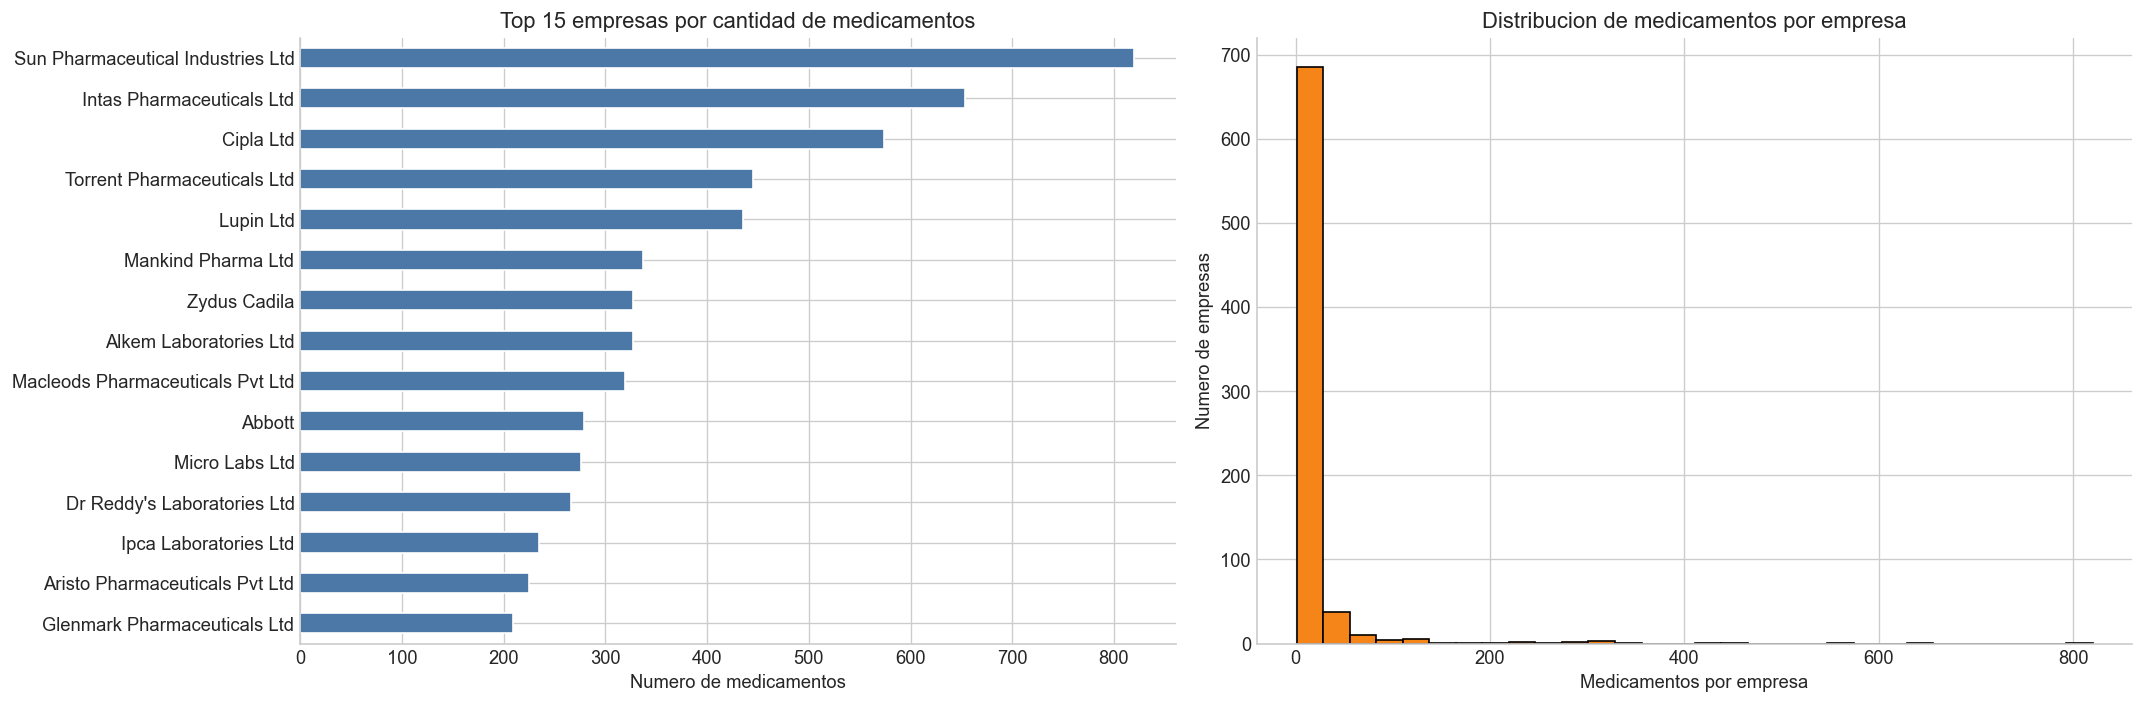

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

empresa_counts.head(15).sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#4C78A8",
    edgecolor="white",
)
axes[0].set_title("Top 15 empresas por cantidad de medicamentos")
axes[0].set_xlabel("Numero de medicamentos")
axes[0].set_ylabel("")

axes[1].hist(empresa_counts, bins=30, color="#F58518", edgecolor="black")
axes[1].set_title("Distribucion de medicamentos por empresa")
axes[1].set_xlabel("Medicamentos por empresa")
axes[1].set_ylabel("Numero de empresas")

plt.tight_layout()
plt.show()


## 4. Integridad y distribucion de las reviews

Como la comparacion por empresa depende de `Excellent Review %`, `Average Review %` y `Poor Review %`, primero revisamos si estas columnas son consistentes y como se distribuyen.

La idea aqui no es resumirlas en una sola metrica, sino observar las tres por separado.


,Excellent Review %,Average Review %,Poor Review %
count,11825.00,11825.00,11825.00
mean,38.52,35.76,25.73
std,25.23,18.27,23.99
min,0.00,0.00,0.00
25%,22.00,27.00,0.00
50%,34.00,35.00,22.00
75%,51.00,47.00,35.00
max,100.00,88.00,100.00


,Excellent Review %,Average Review %,Poor Review %
Excellent Review %,1.00,-0.43,-0.73
Average Review %,-0.43,1.00,-0.31
Poor Review %,-0.73,-0.31,1.00


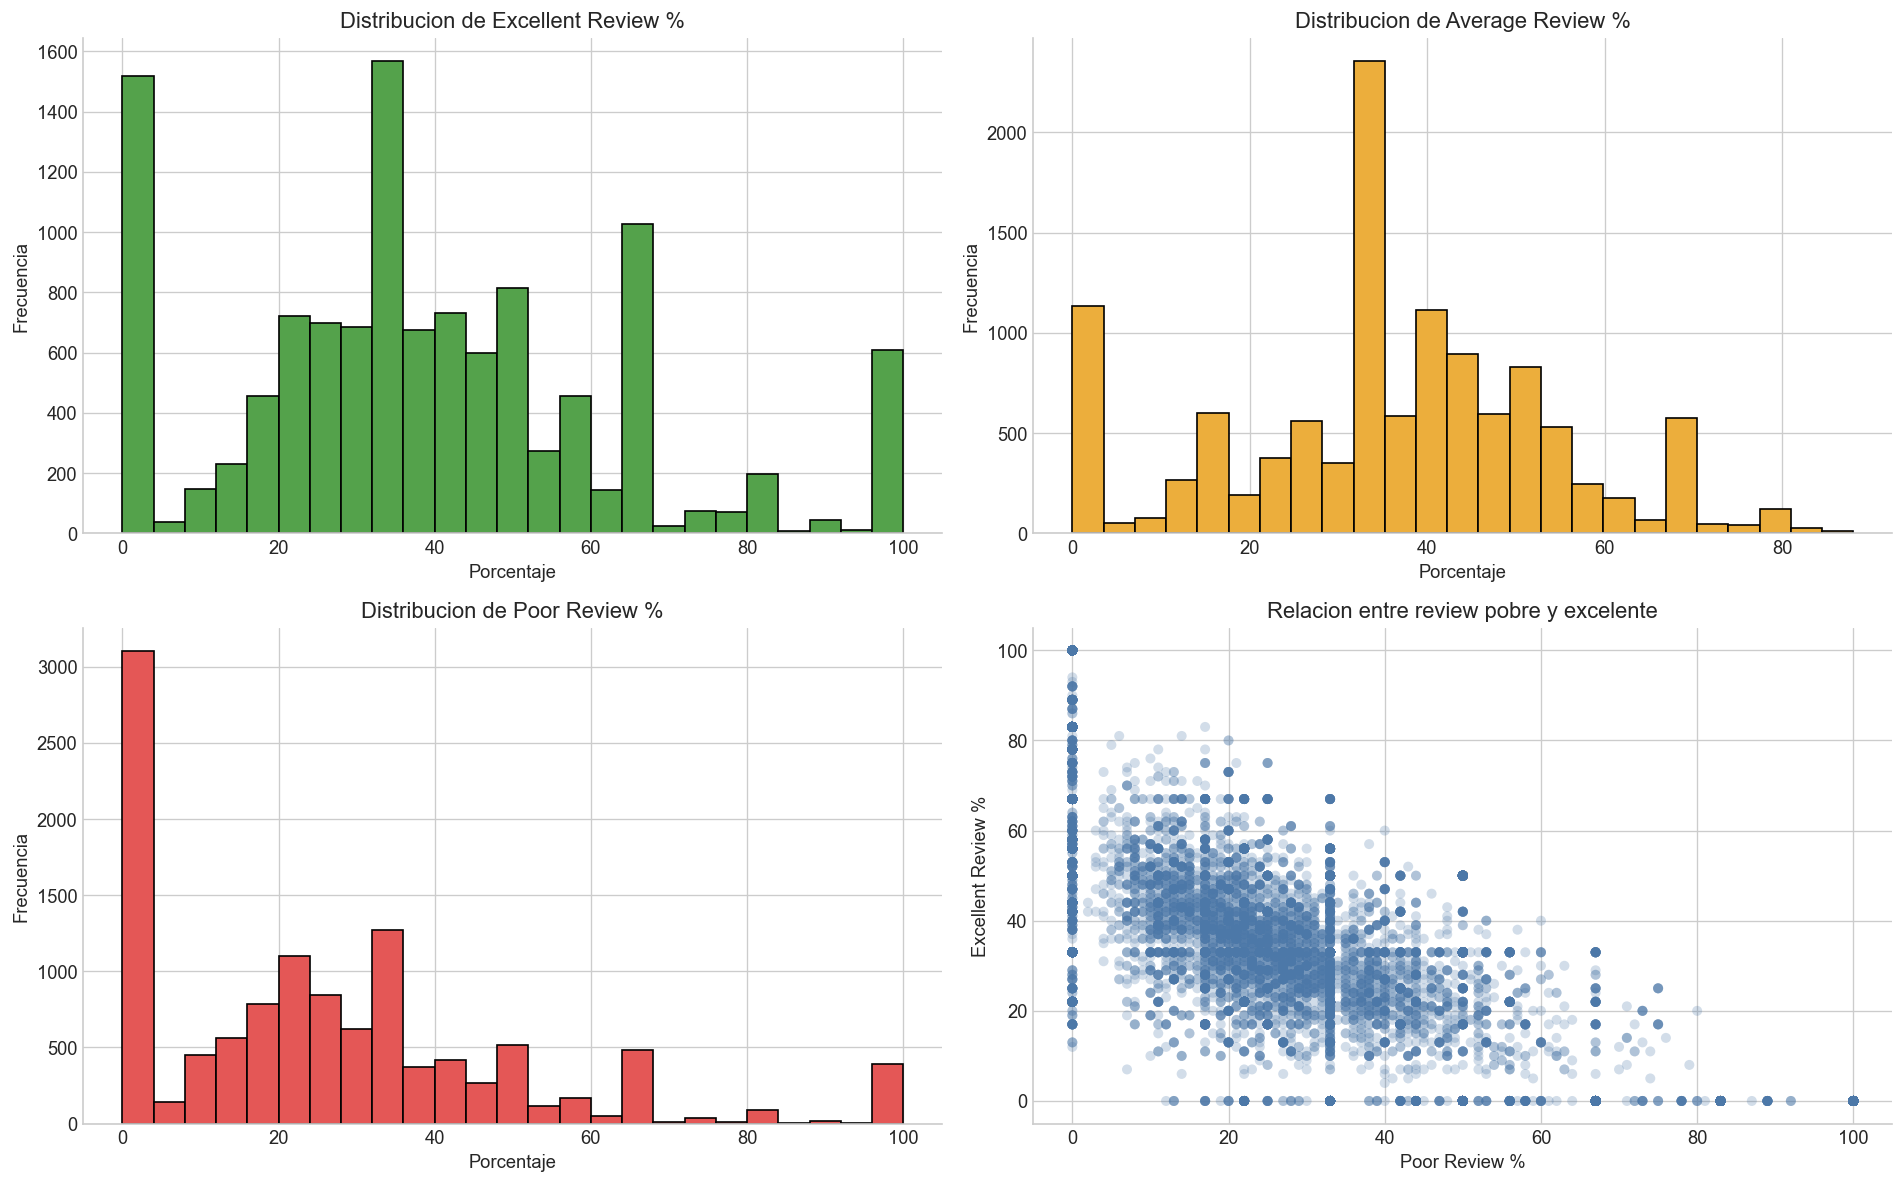

In [6]:
display(review_data.describe().round(2))
display(review_data.corr().round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ["#54A24B", "#ECAE3C", "#E45756"]

for ax, col, color in zip(axes.flat[:3], review_cols, colors):
    ax.hist(review_data[col], bins=25, color=color, edgecolor="black")
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel("Porcentaje")
    ax.set_ylabel("Frecuencia")

axes[1, 1].scatter(
    review_data["Poor Review %"],
    review_data["Excellent Review %"],
    alpha=0.25,
    color="#4C78A8",
    edgecolors="none",
)
axes[1, 1].set_title("Relacion entre review pobre y excelente")
axes[1, 1].set_xlabel("Poor Review %")
axes[1, 1].set_ylabel("Excellent Review %")

plt.tight_layout()
plt.show()


## 5. Composiciones equivalentes entre empresas

En esta parte comprobamos si el dataset realmente permite comparar el mismo medicamento base entre distintos fabricantes.

La clave `composition_key` conserva ingredientes y dosis, pero ignora el orden de escritura. Eso permite detectar casos como `A + B` y `B + A` como una misma composicion.


In [7]:
composition_forms = exploration_df[["Composition", "composition_key"]].drop_duplicates()
multiple_raw_forms = (
    composition_forms.groupby("composition_key")
    .agg(
        n_formas_originales=("Composition", "nunique"),
        ejemplos=("Composition", lambda values: " | ".join(list(values)[:2])),
    )
    .sort_values(["n_formas_originales", "ejemplos"], ascending=[False, True])
)

composition_overview = (
    exploration_df.groupby("composition_key")
    .agg(
        n_empresas=("empresa", "nunique"),
        n_registros=("Medicine Name", "count"),
        n_medicamentos_unicos=("Medicine Name", "nunique"),
    )
    .sort_values(["n_empresas", "n_registros"], ascending=[False, False])
)

print(f"Composiciones compartidas por 2 o mas empresas: {(composition_overview['n_empresas'] >= 2).sum():,}")
print("Ejemplos donde distintas cadenas de Composition colapsan a la misma clave:")
display(multiple_raw_forms[multiple_raw_forms["n_formas_originales"] > 1].head(10))

print("Composiciones mas compartidas entre empresas:")
display(composition_overview.head(15))


Composiciones compartidas por 2 o mas empresas: 1,571
Ejemplos donde distintas cadenas de Composition colapsan a la misma clave:


,n_formas_originales,ejemplos
composition_key,,
Alpha Lipoic Acid (100mg) + Folic Acid (1.5mg) + Methylcobalamin (750mcg) + Pregabalin (75mg) + Vitamin B6 (Pyridoxine)(3mg),2,Alpha Lipoic Acid (100mg) + Folic Acid (1.5mg) + Methylcobalamin (750mcg) + Pregabalin (75mg) + Vitamin B6 (Pyridoxine) (3mg) | Pregabal...
Ambroxol (30mg/5ml) + Guaifenesin (50mg/5ml) + Levosalbutamol (1mg/5ml),2,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml) + Guaifenesin (50mg/5ml) | Levosalbutamol (1mg/5ml) + Ambroxol (30mg/5ml) + Guaifenesin (...
Bromhexine (4mg/5ml) + Guaifenesin (50mg/5ml) + Terbutaline (1.25mg/5ml),2,Guaifenesin (50mg/5ml) + Terbutaline (1.25mg/5ml) + Bromhexine (4mg/5ml) | Terbutaline (1.25mg/5ml) + Bromhexine (4mg/5ml) + Guaifenesin...


Composiciones mas compartidas entre empresas:


,n_empresas,n_registros,n_medicamentos_unicos
composition_key,,,
Levocetirizine (5mg) + Montelukast (10mg),64,77,76
Luliconazole (1% w/w),50,98,64
Domperidone (30mg) + Rabeprazole (20mg),50,60,59
Telmisartan (40mg),46,52,51
Ketoconazole (2% w/w),44,66,58
Domperidone (30mg) + Pantoprazole (40mg),43,47,47
Itraconazole (200mg),42,52,47
Itraconazole (100mg),40,53,48
Glimepiride (2mg) + Metformin (500mg),39,42,42


## 6. Cobertura posible para comparaciones mas representativas

Una vez identificadas las composiciones compartidas, conviene revisar cuantas de ellas tienen una cobertura lo bastante amplia como para priorizarlas despues.

En este EDA usamos una clasificacion exploratoria:
- `debil`: pocas empresas o pocos registros totales para esa composicion;
- `media`: cobertura usable para una comparacion exploratoria mas firme;
- `fuerte`: composiciones compartidas con mejor cobertura relativa dentro del dataset.

Estas etiquetas hablan de cobertura del dataset, no de significancia estadistica. Ademas, los porcentajes de reviews no traen `n_reviews`, asi que siempre deben interpretarse como tendencia.


In [ ]:
comparison_strength_preview = composition_overview.reset_index().copy()
comparison_strength_preview["comparison_strength"] = "debil"
comparison_strength_preview.loc[
    (comparison_strength_preview["n_empresas"] >= 3) & (comparison_strength_preview["n_registros"] >= 5),
    "comparison_strength",
] = "media"
comparison_strength_preview.loc[
    (comparison_strength_preview["n_empresas"] >= 5) & (comparison_strength_preview["n_registros"] >= 10),
    "comparison_strength",
] = "fuerte"

strength_preview_summary = (
    comparison_strength_preview["comparison_strength"]
    .value_counts()
    .rename_axis("comparison_strength")
    .reset_index(name="n_composiciones")
)

display(strength_preview_summary)
display(
    comparison_strength_preview[
        ["composition_key", "n_empresas", "n_registros", "comparison_strength"]
    ].head(15)
)


## 6. Comparacion exploratoria del mismo medicamento base entre empresas

Ahora agregamos por `composition_key` y `empresa` para observar, para una misma formulacion:
- cuantas filas aporta cada empresa;
- como se ven las tres reviews promedio;
- si cambia el numero estimado de efectos secundarios.

Aqui el promedio de efectos puede salir decimal porque ya no representa una fila individual, sino el promedio dentro de cada grupo empresa-composicion.


In [8]:
shared_mask = exploration_df["composition_key"].map(composition_overview["n_empresas"]) >= 2
shared_rows = exploration_df.loc[shared_mask].copy()

composition_company_comparison = (
    shared_rows.groupby(["composition_key", "empresa"], as_index=False)
    .agg(
        n_medicamentos=("Medicine Name", "count"),
        medicamentos_ejemplo=("Medicine Name", lambda values: " | ".join(sorted(set(values))[:3])),
        excellent_mean=("Excellent Review %", "mean"),
        average_mean=("Average Review %", "mean"),
        poor_mean=("Poor Review %", "mean"),
        effect_count_mean=("effect_count_estimate", "mean"),
    )
    .round(2)
)

composition_company_comparison = composition_company_comparison.merge(
    composition_overview[["n_empresas", "n_registros"]],
    left_on="composition_key",
    right_index=True,
    how="left",
)

display(
    composition_company_comparison
    .sort_values(["n_empresas", "n_registros", "excellent_mean"], ascending=[False, False, False])
    .head(20)
)


,composition_key,empresa,n_medicamentos,medicamentos_ejemplo,excellent_mean,average_mean,poor_mean,effect_count_mean,n_empresas,n_registros
5311,Levocetirizine (5mg) + Montelukast (10mg),Athens Labs Ltd,1,Alz Plus Tablet,100.0,0.0,0.0,8.0,64,77
5316,Levocetirizine (5mg) + Montelukast (10mg),Clementia Pharmaceuticals Pvt Ltd,1,Zeemont 5mg/10mg Tablet,100.0,0.0,0.0,8.0,64,77
5319,Levocetirizine (5mg) + Montelukast (10mg),Dr Cure Pharmaceuticals India Pvt Ltd,1,Emimont 5mg/10mg Tablet,100.0,0.0,0.0,8.0,64,77
5344,Levocetirizine (5mg) + Montelukast (10mg),Optho Life Sciences Pvt Ltd,1,Montark-L Tablet,100.0,0.0,0.0,8.0,64,77
5353,Levocetirizine (5mg) + Montelukast (10mg),Shreya Life Sciences Pvt Ltd,1,Recofast LM Tablet,100.0,0.0,0.0,8.0,64,77
5349,Levocetirizine (5mg) + Montelukast (10mg),S H Pharmaceuticals Ltd,1,Alday Duo 5mg/10mg Tablet,78.0,22.0,0.0,8.0,64,77
5361,Levocetirizine (5mg) + Montelukast (10mg),Unimarck Healthcare Ltd,1,Lekast Tablet,75.0,25.0,0.0,8.0,64,77
5333,Levocetirizine (5mg) + Montelukast (10mg),Karnataka Antibiotics & Pharmaceuticals Ltd,1,Rem CC LM 5 mg/10 mg Tablet,73.0,7.0,20.0,8.0,64,77
5304,Levocetirizine (5mg) + Montelukast (10mg),Adley Formulations,1,Admont-LC Tablet,67.0,33.0,0.0,8.0,64,77
5323,Levocetirizine (5mg) + Montelukast (10mg),Eskon Pharma,1,Levokon-M Tablet,67.0,33.0,0.0,8.0,64,77


Composicion explorada: Amoxycillin (200mg) + Clavulanic Acid (28.5mg)


,composition_key,empresa,n_medicamentos,medicamentos_ejemplo,excellent_mean,average_mean,poor_mean,effect_count_mean,n_empresas,n_registros
834,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Micro Labs Ltd,2,Bactoclav Dry Syrup | Erox CV Dry Syrup,100.00,0.00,0.00,6.0,10,18
827,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Aristo Pharmaceuticals Pvt Ltd,3,Mega-CV 228.5mg Dry Syrup | Mega-CV Kid Tablet DT,55.67,2.67,41.67,6.0,10,18
828,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Cipla Ltd,2,Advent 228.5mg Dry Syrup | Novamox CV 228.5mg Dry Syrup,50.00,50.00,0.00,6.0,10,18
832,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Macleods Pharmaceuticals Pvt Ltd,3,Polyclav BD 228.5mg Dry Syrup | Polyclav Kid Tablet | Sensiclav BD 228.5mg Dry Syrup,44.67,33.00,22.33,6.0,10,18
829,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Glaxo SmithKline Pharmaceuticals Ltd,1,Augmentin Duo Oral Suspension,40.00,46.00,14.00,6.0,10,18
835,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Sun Pharmaceutical Industries Ltd,1,Moxclav BD 228.5mg Powder for Oral Suspension,28.00,61.00,11.00,6.0,10,18
831,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Ipca Laboratories Ltd,1,Rapiclav DS Oral Suspension,22.00,45.00,33.00,6.0,10,18
836,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Zuventus Healthcare Ltd,1,Augpen HS 200 mg/28.5 mg Suspension,22.00,45.00,33.00,6.0,10,18
833,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Mankind Pharma Ltd,3,Moxiforce-CV Dry Syrup | Moxikind-CV Dry Syrup | Moxikind-CV Kid Tablet,11.00,40.00,49.00,6.0,10,18
830,Amoxycillin (200mg) + Clavulanic Acid (28.5mg),Indchemie Health Specialities Pvt Ltd,1,Indclav Bid 228 Dry Syrup,0.00,33.00,67.00,6.0,10,18


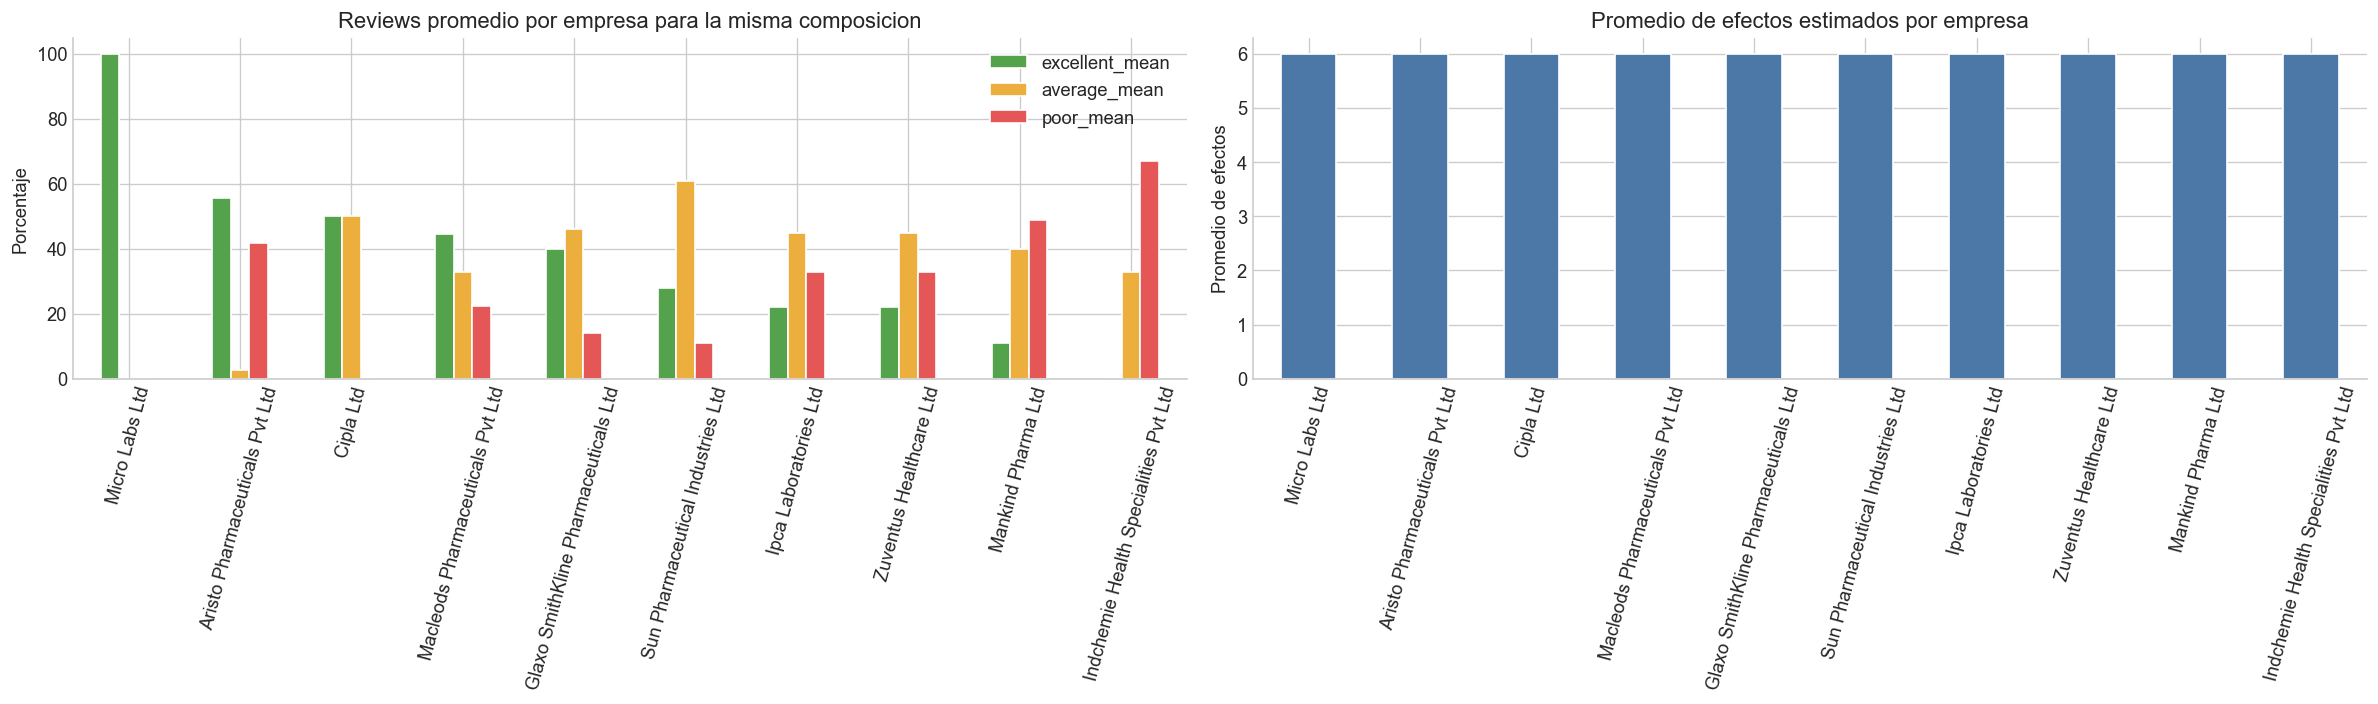

In [9]:
case_pool = composition_overview[(composition_overview["n_empresas"] >= 4) & (composition_overview["n_empresas"] <= 10)]
if case_pool.empty:
    case_pool = composition_overview[composition_overview["n_empresas"] >= 2]

composition_to_review = case_pool.sort_values(["n_empresas", "n_registros"], ascending=[False, False]).index[0]
case_study = (
    composition_company_comparison[
        composition_company_comparison["composition_key"] == composition_to_review
    ]
    .sort_values(["excellent_mean", "poor_mean"], ascending=[False, True])
)

print(f"Composicion explorada: {composition_to_review}")
display(case_study)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

case_study.set_index("empresa")[["excellent_mean", "average_mean", "poor_mean"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#54A24B", "#ECAE3C", "#E45756"],
    edgecolor="white",
)
axes[0].set_title("Reviews promedio por empresa para la misma composicion")
axes[0].set_xlabel("")
axes[0].set_ylabel("Porcentaje")
axes[0].tick_params(axis="x", rotation=75)

case_study.set_index("empresa")["effect_count_mean"].plot(
    kind="bar",
    ax=axes[1],
    color="#4C78A8",
    edgecolor="white",
)
axes[1].set_title("Promedio de efectos estimados por empresa")
axes[1].set_xlabel("")
axes[1].set_ylabel("Promedio de efectos")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()


## 7. Variacion, outliers y posibles inconsistencias entre empresas para la misma composicion

Si dos empresas venden la misma composicion, interesa medir cuanto cambia la aprobacion y cuanto cambia el numero de efectos estimados.

Esta seccion resume la variacion por composicion y marca posibles outliers con la regla IQR. En una variable muy concentrada, como `effect_count_mean`, un umbral IQR igual a cero implica que cualquier variacion positiva merece inspeccion manual.


In [10]:
variation_summary = (
    composition_company_comparison.groupby("composition_key")
    .agg(
        n_empresas=("empresa", "nunique"),
        n_registros=("n_medicamentos", "sum"),
        excellent_range=("excellent_mean", lambda s: round(s.max() - s.min(), 2)),
        average_range=("average_mean", lambda s: round(s.max() - s.min(), 2)),
        poor_range=("poor_mean", lambda s: round(s.max() - s.min(), 2)),
        effect_range=("effect_count_mean", lambda s: round(s.max() - s.min(), 2)),
    )
    .sort_values(["n_empresas", "n_registros"], ascending=[False, False])
)

variation_presence = pd.DataFrame(
    {
        "metrica": [
            "composiciones_con_variacion_en_excellent",
            "composiciones_con_variacion_en_average",
            "composiciones_con_variacion_en_poor",
            "composiciones_con_variacion_en_efectos",
        ],
        "conteo": [
            int((variation_summary["excellent_range"] > 0).sum()),
            int((variation_summary["average_range"] > 0).sum()),
            int((variation_summary["poor_range"] > 0).sum()),
            int((variation_summary["effect_range"] > 0).sum()),
        ],
        "proporcion": [
            round((variation_summary["excellent_range"] > 0).mean(), 3),
            round((variation_summary["average_range"] > 0).mean(), 3),
            round((variation_summary["poor_range"] > 0).mean(), 3),
            round((variation_summary["effect_range"] > 0).mean(), 3),
        ],
    }
)

outlier_rows = []
for col in ["excellent_range", "average_range", "poor_range", "effect_range"]:
    q1 = variation_summary[col].quantile(0.25)
    q3 = variation_summary[col].quantile(0.75)
    iqr = q3 - q1
    upper = round(q3 + 1.5 * iqr, 2)
    outlier_rows.append(
        {
            "variable": col,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "umbral_superior_iqr": upper,
            "n_outliers": int((variation_summary[col] > upper).sum()),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)

display(variation_presence)
display(outlier_summary)

print("Composiciones con mayor variacion en reviews y efectos entre empresas:")
display(
    variation_summary
    .sort_values(["excellent_range", "poor_range", "effect_range"], ascending=[False, False, False])
    .head(15)
)


,metrica,conteo,proporcion
0,composiciones_con_variacion_en_excellent,1540,0.980
1,composiciones_con_variacion_en_average,1550,0.987
2,composiciones_con_variacion_en_poor,1504,0.957
3,composiciones_con_variacion_en_efectos,57,0.036


,variable,q1,q3,iqr,umbral_superior_iqr,n_outliers
0,excellent_range,20.00,67.0,47.00,137.50,0
1,average_range,17.00,51.5,34.50,103.25,0
2,poor_range,17.25,67.0,49.75,141.62,0
3,effect_range,0.00,0.0,0.00,0.00,57


Composiciones con mayor variacion en reviews y efectos entre empresas:


,n_empresas,n_registros,excellent_range,average_range,poor_range,effect_range
composition_key,,,,,,
Telmisartan (40mg),46,52,100.0,67.0,100.0,3.0
Liquid Paraffin (1.25ml) + Milk Of Magnesia (3.75ml) + Sodium Picosulfate (3.33mg),11,11,100.0,58.0,100.0,2.0
Ketoconazole (2% w/w),44,66,100.0,67.0,100.0,1.0
Tacrolimus (0.1% w/v),7,8,100.0,47.0,100.0,1.0
Ondansetron (2mg),4,6,100.0,44.0,100.0,1.0
Pantoprazole (40mg),27,36,100.0,67.0,100.0,0.5
Levocetirizine (5mg) + Montelukast (10mg),64,77,100.0,60.0,100.0,0.0
Luliconazole (1% w/w),50,98,100.0,78.0,100.0,0.0
Domperidone (30mg) + Rabeprazole (20mg),50,60,100.0,72.0,100.0,0.0


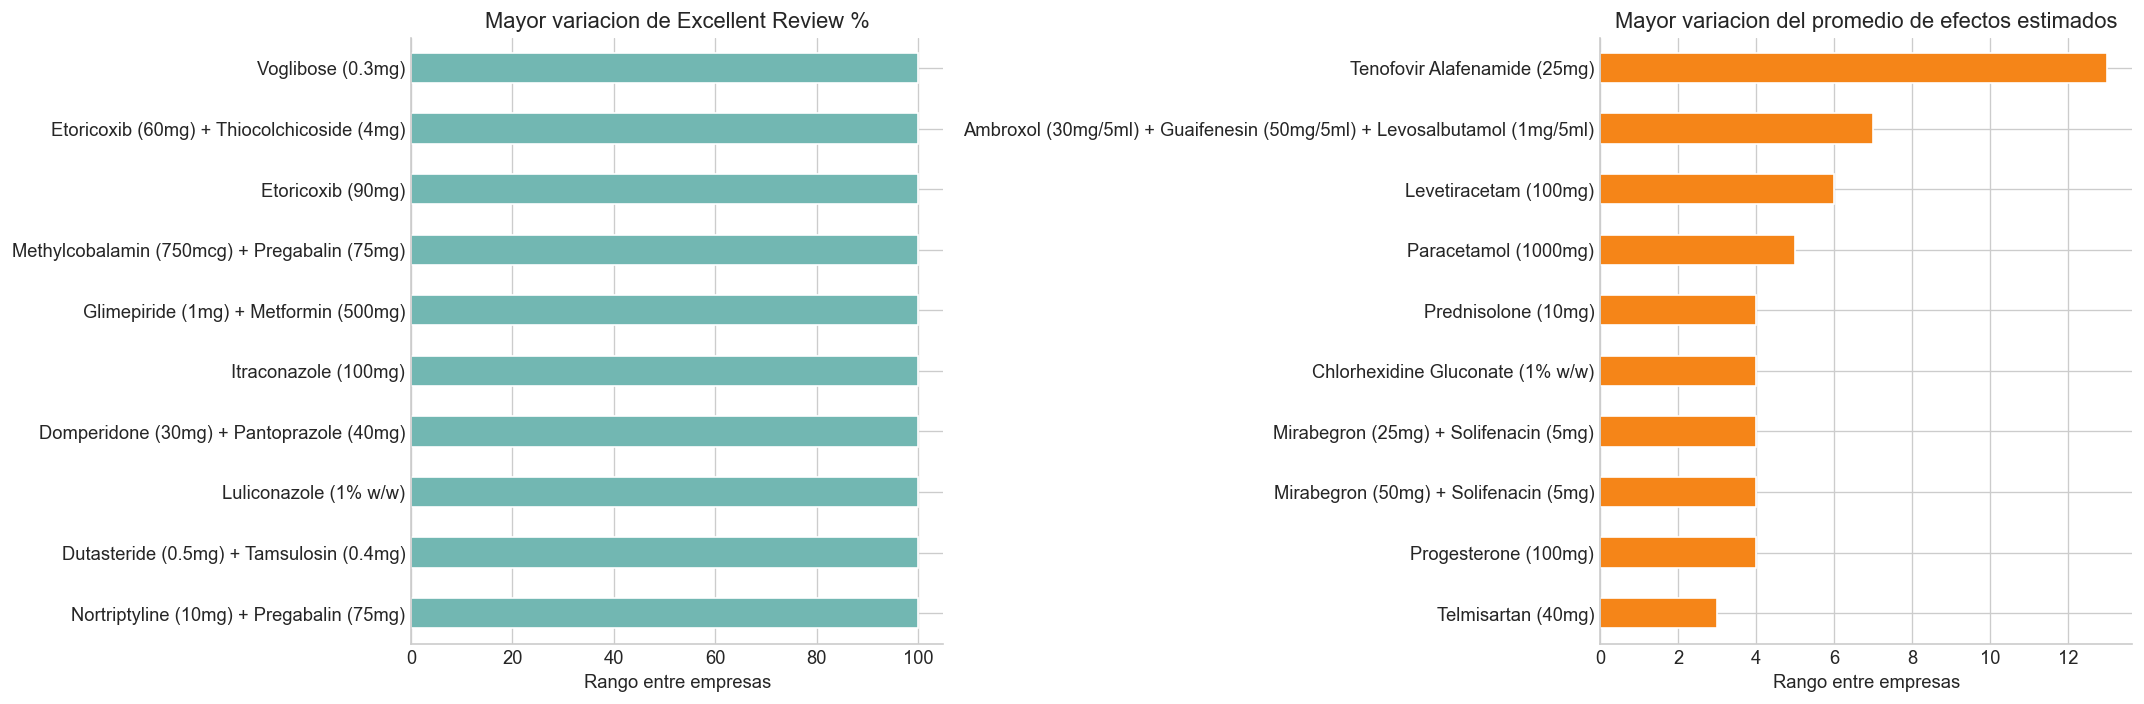

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_review_variation = variation_summary.sort_values(
    ["excellent_range", "poor_range", "average_range"],
    ascending=[False, False, False],
).head(10)

top_effect_variation = variation_summary.sort_values(
    ["effect_range", "excellent_range", "n_empresas"],
    ascending=[False, False, False],
).head(10)

top_review_variation.sort_values("excellent_range").plot(
    y="excellent_range",
    kind="barh",
    ax=axes[0],
    legend=False,
    color="#72B7B2",
    edgecolor="white",
)
axes[0].set_title("Mayor variacion de Excellent Review %")
axes[0].set_xlabel("Rango entre empresas")
axes[0].set_ylabel("")

top_effect_variation.sort_values("effect_range").plot(
    y="effect_range",
    kind="barh",
    ax=axes[1],
    legend=False,
    color="#F58518",
    edgecolor="white",
)
axes[1].set_title("Mayor variacion del promedio de efectos estimados")
axes[1].set_xlabel("Rango entre empresas")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 8. Relaciones entre variables en las composiciones comparables

Finalmente, observamos si existe alguna relacion descriptiva entre reviews y efectos en la tabla agregada por empresa-composicion.

Estas relaciones son exploratorias: no implican causalidad ni prueban por si solas que una empresa fabrique mejor o peor.


,n_medicamentos,excellent_mean,average_mean,poor_mean,effect_count_mean
n_medicamentos,1.00,-0.02,0.02,0.00,-0.04
excellent_mean,-0.02,1.00,-0.43,-0.73,0.04
average_mean,0.02,-0.43,1.00,-0.31,-0.01
poor_mean,0.00,-0.73,-0.31,1.00,-0.04
effect_count_mean,-0.04,0.04,-0.01,-0.04,1.00


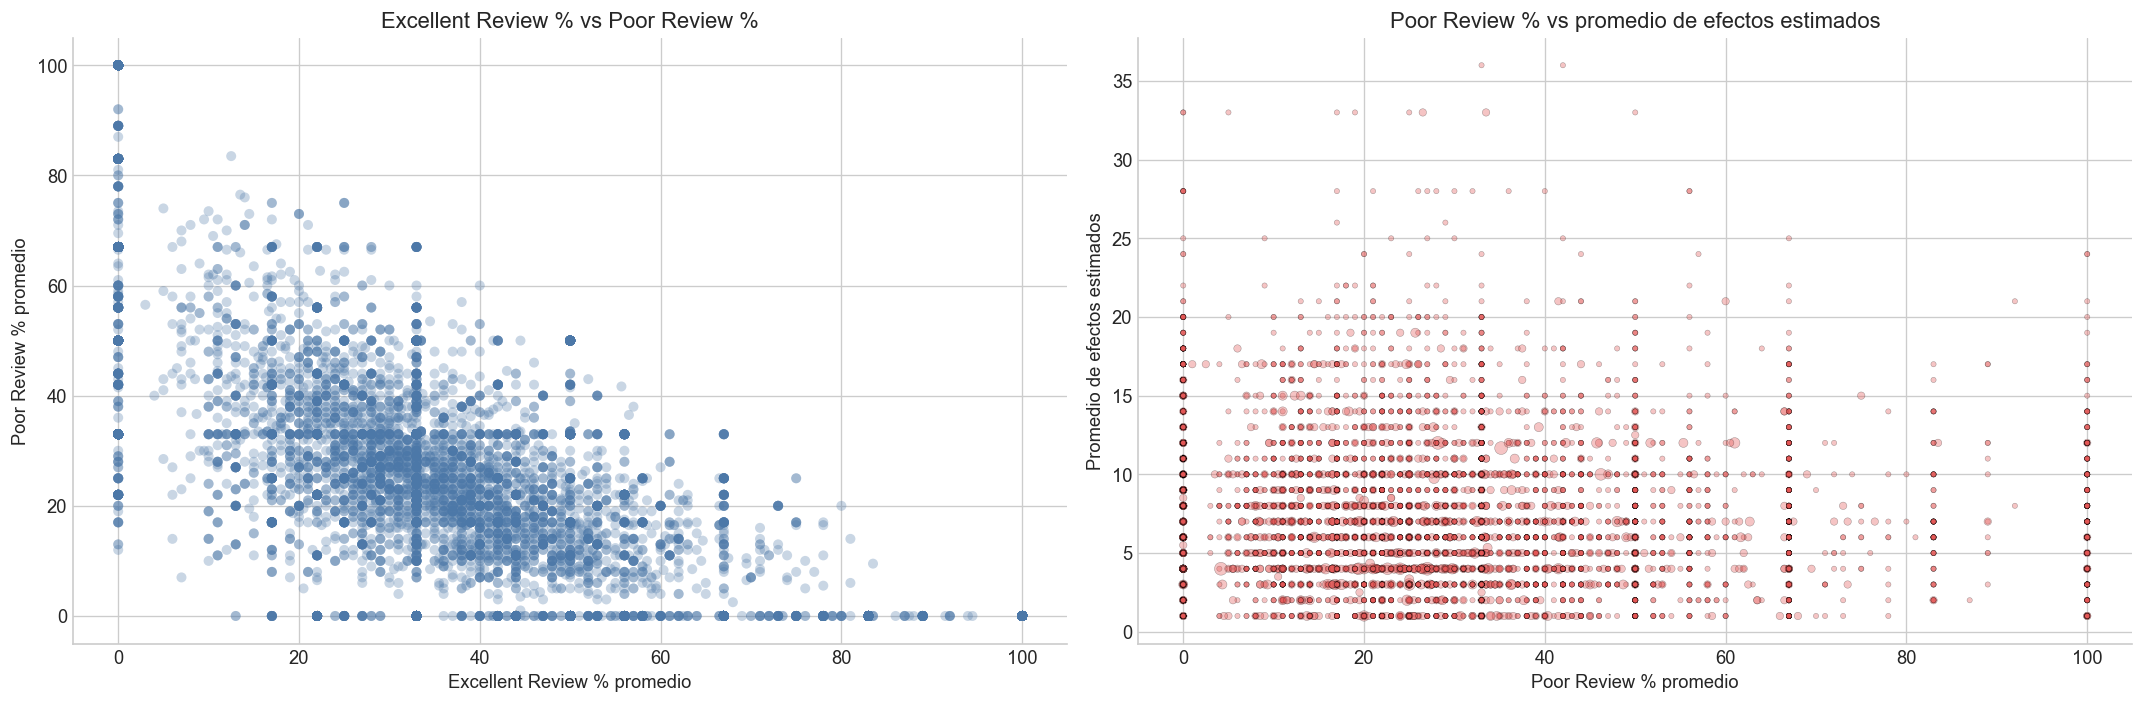

In [12]:
correlation_table = composition_company_comparison[
    ["n_medicamentos", "excellent_mean", "average_mean", "poor_mean", "effect_count_mean"]
].corr().round(2)

display(correlation_table)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].scatter(
    composition_company_comparison["excellent_mean"],
    composition_company_comparison["poor_mean"],
    alpha=0.3,
    color="#4C78A8",
    edgecolors="none",
)
axes[0].set_title("Excellent Review % vs Poor Review %")
axes[0].set_xlabel("Excellent Review % promedio")
axes[0].set_ylabel("Poor Review % promedio")

axes[1].scatter(
    composition_company_comparison["poor_mean"],
    composition_company_comparison["effect_count_mean"],
    s=composition_company_comparison["n_medicamentos"] * 10,
    alpha=0.35,
    color="#E45756",
    edgecolors="black",
    linewidths=0.3,
)
axes[1].set_title("Poor Review % vs promedio de efectos estimados")
axes[1].set_xlabel("Poor Review % promedio")
axes[1].set_ylabel("Promedio de efectos estimados")

plt.tight_layout()
plt.show()


## 9. Hallazgos exploratorios y decisiones preliminares

Este EDA deja bien encaminadas las decisiones del foco:
- revisar los duplicados exactos antes de comparar empresas;
- mantener una validacion explicita de las tres reviews, porque aqui son la base de la comparacion;
- conservar una forma canonica de `Composition` para comparar la misma formulacion entre empresas sin depender del orden del texto;
- evitar rankings globales de empresas y comparar fabricantes solo dentro de la misma composicion;
- priorizar composiciones con mejor cobertura del dataset y dejar visible el tamano de muestra de cada comparacion;
- inspeccionar con detalle las composiciones que muestran grandes diferencias de reviews entre fabricantes;
- revisar manualmente los pocos casos donde tambien cambian los efectos secundarios estimados para la misma composicion;
- dejar explicito que los porcentajes de reviews no incluyen `n_reviews`, por lo que describen tendencia y no significancia estadistica.

Con esto, el siguiente notebook puede enfocarse en limpiar y transformar solo lo necesario para que la comparacion entre empresas sea mas robusta y defendible.
